In [22]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from utils import plot_learning_curve, plot_roc
from sklearn.model_selection import StratifiedKFold


# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()
# -------------------------------


# Load Data
# -------------------------------
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test  = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')
test_ids = X_test['PassengerId']
X_test.drop(columns=['PassengerId'], inplace=True)

# Flatten target if needed
# Map target to numeric
target = 'Survived'

y_train_numeric = y_train[target]


num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of classes: 2
X_train shape: (891, 13)
X_test shape: (418, 13)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "25.0.1" 2025-09-16; OpenJDK Runtime Environment (build 25.0.1); OpenJDK 64-Bit Server VM (build 25.0.1, mixed mode, sharing)
  Starting server from /home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpnpzg5_tz
  JVM stdout: /tmp/tmpnpzg5_tz/h2o_ismail_started_from_python.out
  JVM stderr: /tmp/tmpnpzg5_tz/h2o_ismail_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Africa/Algiers
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 16 days
H2O_cluster_name:,H2O_from_python_ismail_mmlwnj
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.984 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'relatives', 'not_alone', 'Deck', 'Title', 'Age_Class', 'Fare_Per_Person']
Target: Survived
AutoML training completed in 129.34 seconds
model_id                                                  logloss       auc     aucpr    mean_per_class_error      rmse       mse
StackedEnsemble_AllModels_1_AutoML_1_20260210_92142      0.407363  0.870892  0.851088                0.177164  0.353308  0.124826
GBM_2_AutoML_1_20260210_92142                            0.409805  0.866956  0.848827                0.179249  0.353892  0.12524
StackedEnsemble_BestOfFamily_1_AutoML_1_20260210_92142   0.411338  0.868397  0.8497                  0.176253  0.354814  0.125893
GBM_3_AutoML_1_20260210_92142                            0.41232   0.869574  0.854658                0.175367  0.356571  0.127143
GBM_5_AutoML_1_20260210_92142                            0.413727  0.871577  0.852637                0.170981  0.357761  0.127993
GBM_grid_1_A

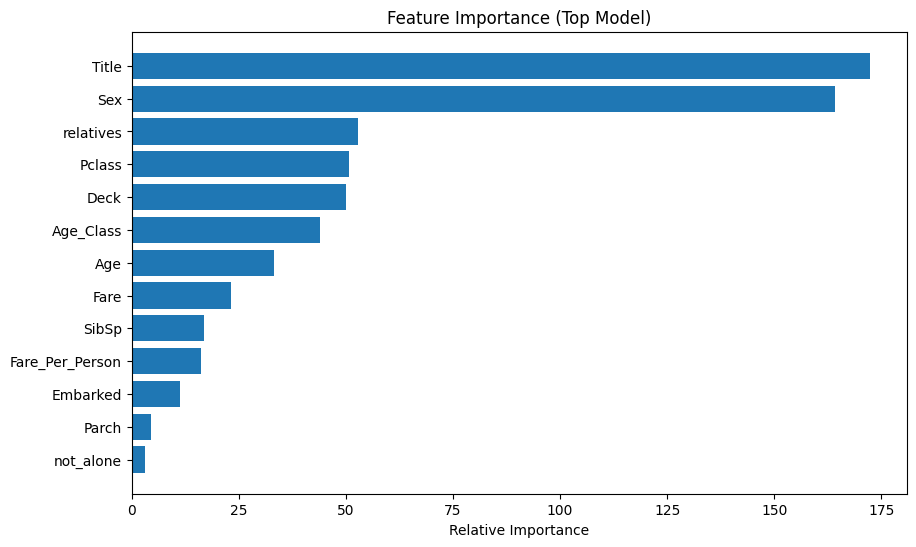

Submission saved!


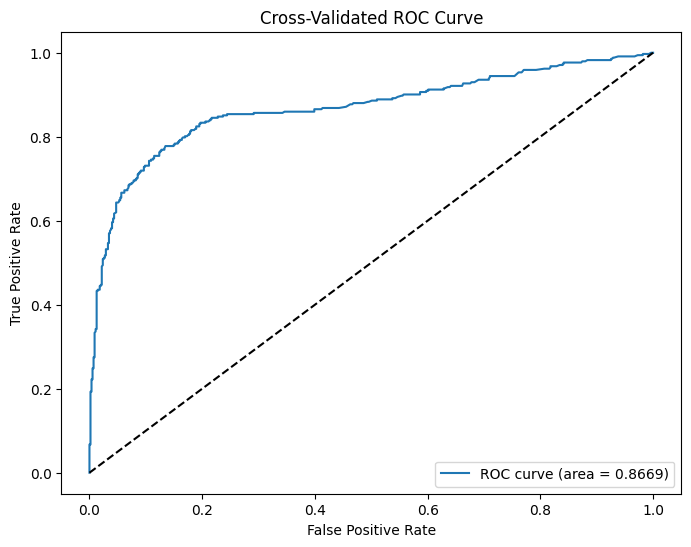

H2O session _sid_93e7 closed.


In [23]:
# -------------------------------
# Advanced H2O ML Pipeline
# -------------------------------

import h2o
from h2o.automl import H2OAutoML
from h2o.estimators.stackedensemble import H2OStackedEnsembleEstimator
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import time

# -------------------------------
# Initialize H2O
# -------------------------------
h2o.init(max_mem_size="8G")  # Adjust based on your system RAM

# -------------------------------
# Load Data
# -------------------------------
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test  = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')

test_ids = X_test['PassengerId']
X_test.drop(columns=['PassengerId'], inplace=True)

target = 'Survived'
y_train_numeric = y_train[target]

# -------------------------------
# Convert to H2O Frames
# -------------------------------
train_df = X_train.copy()
train_df[target] = y_train_numeric

train_hf = h2o.H2OFrame(train_df)
test_hf  = h2o.H2OFrame(X_test)

features = [col for col in X_train.columns]
target_col = target

# Make target categorical
train_hf[target_col] = train_hf[target_col].asfactor()

print(f"Features: {features}")
print(f"Target: {target_col}")

# -------------------------------
# H2O AutoML
# -------------------------------
aml = H2OAutoML(
    max_models=20,
    seed=42,
    max_runtime_secs=1800,
    nfolds=5,
    keep_cross_validation_predictions=True,
    sort_metric="logloss"
)

start_time = time.time()
aml.train(x=features, y=target_col, training_frame=train_hf)
end_time = time.time()
print(f"AutoML training completed in {end_time - start_time:.2f} seconds")

# -------------------------------
# Leaderboard
# -------------------------------
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

best_model = aml.leader
print(f"Best model: {best_model.model_id}")

# -------------------------------
# Evaluate CV Metrics Safely
# -------------------------------
# Stacked Ensembles may not return CV holdout predictions
def get_cv_predictions(model):
    try:
        cv_preds = model.cross_validation_holdout_predictions()
        if cv_preds is not None:
            return h2o.as_list(cv_preds)['p1'].values
        else:
            return None
    except:
        return None

cv_pred_proba = get_cv_predictions(best_model)

# If CV predictions are None (ensemble), pick top non-ensemble model
if cv_pred_proba is None:
    print("Leader is ensemble; using top GBM for CV metrics")
    lb_df = aml.leaderboard.as_data_frame()
    for i, row in lb_df.iterrows():
        if "StackedEnsemble" not in row['model_id']:
            top_model_id = row['model_id']
            break
    top_model = h2o.get_model(top_model_id)
    cv_pred_proba = get_cv_predictions(top_model)

roc_auc = roc_auc_score(y_train_numeric, cv_pred_proba)
print(f"CV ROC-AUC: {roc_auc:.4f}")

# Optional: Feature importance for top non-ensemble
if hasattr(top_model, "varimp"):
    varimp = top_model.varimp(use_pandas=True)
    plt.figure(figsize=(10,6))
    plt.barh(varimp['variable'], varimp['relative_importance'])
    plt.xlabel('Relative Importance')
    plt.title('Feature Importance (Top Model)')
    plt.gca().invert_yaxis()
    plt.show()

# -------------------------------
# Predict on Test Data
# -------------------------------
pred_hf = best_model.predict(test_hf)
pred_df = h2o.as_list(pred_hf)
y_test_proba = pred_df['p1'].values

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": y_test_proba
})
submission.to_csv("h2o_automl_submission.csv", index=False)
print("Submission saved!")

# -------------------------------
# ROC Curve
# -------------------------------
fpr, tpr, _ = roc_curve(y_train_numeric, cv_pred_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc_val:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validated ROC Curve')
plt.legend(loc='lower right')
plt.show()

# -------------------------------
# Shutdown H2O
# -------------------------------
h2o.shutdown(prompt=False)


In [25]:
# -------------------------------
# Advanced H2O ML Pipeline - Hyper-tuned & Stacked
# -------------------------------

import h2o
from h2o.automl import H2OAutoML
from h2o.estimators import H2OGradientBoostingEstimator, H2OXGBoostEstimator, H2ODeepLearningEstimator
from h2o.estimators.stackedensemble import H2OStackedEnsembleEstimator
from h2o.grid.grid_search import H2OGridSearch
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import time

# -------------------------------
# Initialize H2O Cluster
# -------------------------------
h2o.init(max_mem_size="8G")  # Your cluster has 16 cores and ~8GB free

# -------------------------------
# Load Data
# -------------------------------
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test  = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')

test_ids = X_test['PassengerId']
X_test.drop(columns=['PassengerId'], inplace=True)

target = 'Survived'
y_train_numeric = y_train[target]

train_df = X_train.copy()
train_df[target] = y_train_numeric

train_hf = h2o.H2OFrame(train_df)
test_hf  = h2o.H2OFrame(X_test)

features = [col for col in X_train.columns]
target_col = target
train_hf[target_col] = train_hf[target_col].asfactor()

# -------------------------------
# Hyperparameter Grid Search for GBM
# -------------------------------
gbm_params = {
    "max_depth": [3, 5, 7, 9],
    "learn_rate": [0.01, 0.05, 0.1],
    "ntrees": [100, 200, 500],
    "sample_rate": [0.7, 0.8, 1.0],
    "col_sample_rate": [0.7, 0.8, 1.0]
}

gbm_grid = H2OGridSearch(
    model=H2OGradientBoostingEstimator,
    hyper_params=gbm_params,
    grid_id="gbm_grid_advanced",
    search_criteria={"strategy": "Cartesian"}
)

gbm_grid.train(x=features, y=target_col, training_frame=train_hf, nfolds=5, seed=42, keep_cross_validation_predictions=True)

# Select best GBM
best_gbm = gbm_grid.get_grid(sort_by="logloss", decreasing=False).models[0]
print(f"Best GBM: {best_gbm.model_id}")

# -------------------------------
# Hyperparameter Grid for XGBoost (optional)
# -------------------------------
xgb_params = {
    "max_depth": [3, 5, 7],
    "learn_rate": [0.01, 0.05, 0.1],
    "ntrees": [100, 200, 500],
    "sample_rate": [0.7, 0.8, 1.0],
    "col_sample_rate": [0.7, 0.8, 1.0]
}

xgb_grid = H2OGridSearch(
    model=H2OXGBoostEstimator,
    hyper_params=xgb_params,
    grid_id="xgb_grid_advanced",
    search_criteria={"strategy": "Cartesian"}
)

xgb_grid.train(x=features, y=target_col, training_frame=train_hf, nfolds=5, seed=42, keep_cross_validation_predictions=True)
best_xgb = xgb_grid.get_grid(sort_by="logloss", decreasing=False).models[0]
print(f"Best XGBoost: {best_xgb.model_id}")

# -------------------------------
# Optional: DeepLearning model
# -------------------------------
dl_model = H2ODeepLearningEstimator(
    hidden=[50,50],
    epochs=50,
    seed=42,
    nfolds=5,
    keep_cross_validation_predictions=True
)
dl_model.train(x=features, y=target_col, training_frame=train_hf)

# -------------------------------
# Manual Stacked Ensemble
# -------------------------------
ensemble = H2OStackedEnsembleEstimator(
    model_id="stacked_ensemble_advanced",
    base_models=[best_gbm.model_id, best_xgb.model_id, dl_model.model_id],
    metalearner_algorithm="glm",
    metalearner_nfolds=5
)

ensemble.train(x=features, y=target_col, training_frame=train_hf)
print(f"Stacked Ensemble trained: {ensemble.model_id}")

# -------------------------------
# Evaluate CV Metrics
# -------------------------------
cv_pred = ensemble.cross_validation_holdout_predictions()
cv_pred_proba = h2o.as_list(cv_pred)['p1'].values
roc_auc_val = roc_auc_score(y_train_numeric, cv_pred_proba)
print(f"Ensemble CV ROC-AUC: {roc_auc_val:.4f}")

# -------------------------------
# Feature Importance (from best GBM)
# -------------------------------
if hasattr(best_gbm, "varimp"):
    varimp = best_gbm.varimp(use_pandas=True)
    plt.figure(figsize=(10,6))
    plt.barh(varimp['variable'], varimp['relative_importance'])
    plt.xlabel('Relative Importance')
    plt.title('Feature Importance (GBM)')
    plt.gca().invert_yaxis()
    plt.show()

# -------------------------------
# SHAP Values (optional)
# -------------------------------
shap_df = best_gbm.predict_contributions(train_hf)
print("SHAP contributions head:")
print(h2o.as_list(shap_df).head())

# -------------------------------
# Predict on Test Data
# -------------------------------
pred_hf = ensemble.predict(test_hf)
pred_df = h2o.as_list(pred_hf)
y_test_proba = pred_df['p1'].values

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": y_test_proba
})
submission.to_csv("h2o_advanced_submission.csv", index=False)
print("Submission saved!")

# -------------------------------
# ROC Curve
# -------------------------------
fpr, tpr, _ = roc_curve(y_train_numeric, cv_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc_val:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validated ROC Curve')
plt.legend(loc='lower right')
plt.show()

# -------------------------------
# Shutdown H2O
# -------------------------------
h2o.shutdown(prompt=False)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "25.0.1" 2025-09-16; OpenJDK Runtime Environment (build 25.0.1); OpenJDK 64-Bit Server VM (build 25.0.1, mixed mode, sharing)
  Starting server from /home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp4_fpmb_9
  JVM stdout: /tmp/tmp4_fpmb_9/h2o_ismail_started_from_python.out
  JVM stderr: /tmp/tmp4_fpmb_9/h2o_ismail_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Africa/Algiers
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 16 days
H2O_cluster_name:,H2O_from_python_ismail_qhw0vz
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.980 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


H2OConnectionError: Unexpected HTTP error: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

advanced H2O + Bayesian hyper-tuned stacked ensemble pipeline:

In [ ]:
# -------------------------------
# Advanced H2O ML Pipeline - Accuracy-focused & Robust
# -------------------------------

import h2o
from h2o.estimators import H2OGradientBoostingEstimator, H2OXGBoostEstimator, H2ODeepLearningEstimator
from h2o.estimators.stackedensemble import H2OStackedEnsembleEstimator
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import optuna
import time

# -------------------------------
# Initialize H2O Cluster
# -------------------------------
h2o.init(max_mem_size="8G")
h2o.no_progress()

# -------------------------------
# Load Data
# -------------------------------
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test  = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')

test_ids = X_test['PassengerId']
X_test.drop(columns=['PassengerId'], inplace=True)

target = 'Survived'
y_train_numeric = y_train[target]

train_df = X_train.copy()
train_df[target] = y_train_numeric

train_hf = h2o.H2OFrame(train_df)
test_hf  = h2o.H2OFrame(X_test)

features = list(X_train.columns)
target_col = target
train_hf[target_col] = train_hf[target_col].asfactor()

# -------------------------------
# Helper: Robust CV Predictions
# -------------------------------
def get_cv_predictions_safe(model, threshold=0.5):
    """
    Returns 0/1 CV predictions for a model or ensemble.
    Handles stacked ensembles and missing CV predictions.
    """
    try:
        cv_preds = model.cross_validation_holdout_predictions()
        if cv_preds is not None:
            prob = h2o.as_list(cv_preds, use_pandas=True)['p1'].values
            return (prob >= threshold).astype(int)
        elif isinstance(model, H2OStackedEnsembleEstimator):
            # fallback to top base model if ensemble has no CV predictions
            for base_id in model.base_models:
                base_model = h2o.get_model(base_id)
                preds = get_cv_predictions_safe(base_model, threshold)
                if preds is not None:
                    return preds
        else:
            return None
    except:
        return None

# -------------------------------
# Optuna Bayesian Tuning for GBM
# -------------------------------
def tune_gbm(trial):
    params = {
        "ntrees": trial.suggest_int("ntrees", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learn_rate": trial.suggest_float("learn_rate", 0.01, 0.2, log=True),
        "sample_rate": trial.suggest_float("sample_rate", 0.7, 1.0),
        "col_sample_rate": trial.suggest_float("col_sample_rate", 0.7, 1.0),
        "seed": 42,
        "nfolds": 5,
        "keep_cross_validation_predictions": True
    }
    model = H2OGradientBoostingEstimator(**params)
    model.train(x=features, y=target_col, training_frame=train_hf)
    cv_class = get_cv_predictions_safe(model)
    return accuracy_score(y_train_numeric, cv_class)

study_gbm = optuna.create_study(direction="maximize")
study_gbm.optimize(tune_gbm, n_trials=30)

best_gbm_params = study_gbm.best_params
best_gbm = H2OGradientBoostingEstimator(**best_gbm_params, nfolds=5, keep_cross_validation_predictions=True)
best_gbm.train(x=features, y=target_col, training_frame=train_hf)
print(f"Best GBM params: {best_gbm_params}")

# -------------------------------
# Optuna Bayesian Tuning for XGBoost
# -------------------------------
def tune_xgb(trial):
    params = {
        "ntrees": trial.suggest_int("ntrees", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learn_rate": trial.suggest_float("learn_rate", 0.01, 0.2, log=True),
        "sample_rate": trial.suggest_float("sample_rate", 0.7, 1.0),
        "col_sample_rate": trial.suggest_float("col_sample_rate", 0.7, 1.0),
        "seed": 42,
        "nfolds": 5,
        "keep_cross_validation_predictions": True
    }
    model = H2OXGBoostEstimator(**params)
    model.train(x=features, y=target_col, training_frame=train_hf)
    cv_class = get_cv_predictions_safe(model)
    return accuracy_score(y_train_numeric, cv_class)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(tune_xgb, n_trials=20)

best_xgb_params = study_xgb.best_params
best_xgb = H2OXGBoostEstimator(**best_xgb_params, nfolds=5, keep_cross_validation_predictions=True)
best_xgb.train(x=features, y=target_col, training_frame=train_hf)
print(f"Best XGBoost params: {best_xgb_params}")

# -------------------------------
# Deep Learning (optional)
# -------------------------------
dl_model = H2ODeepLearningEstimator(hidden=[50,50], epochs=50, seed=42, nfolds=5, keep_cross_validation_predictions=True)
dl_model.train(x=features, y=target_col, training_frame=train_hf)

# -------------------------------
# Stacked Ensemble
# -------------------------------
ensemble = H2OStackedEnsembleEstimator(
    model_id="stacked_ensemble_accuracy",
    base_models=[best_gbm.model_id, best_xgb.model_id, dl_model.model_id],
    metalearner_algorithm="glm",
    metalearner_nfolds=5
)
ensemble.train(x=features, y=target_col, training_frame=train_hf)

# -------------------------------
# CV Accuracy
# -------------------------------
cv_pred_class = get_cv_predictions_safe(ensemble)
if cv_pred_class is not None:
    acc = accuracy_score(y_train_numeric, cv_pred_class)
    print(f"Ensemble CV Accuracy: {acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_train_numeric, cv_pred_class)
    print("CV Confusion Matrix:\n", cm)
else:
    print("CV predictions unavailable. Ensure all base models have keep_cross_validation_predictions=True")

# -------------------------------
# Predict on Test Data
# -------------------------------
pred_hf = ensemble.predict(test_hf)
y_test_proba = h2o.as_list(pred_hf, use_pandas=True)['p1'].values
y_test_class = (y_test_proba >= 0.5).astype(int)

submission = pd.DataFrame({"PassengerId": test_ids, "Survived": y_test_class})
submission.to_csv("h2o_accuracy_ensemble_submission.csv", index=False)
print("Submission saved!")

# -------------------------------
# Shutdown H2O
# -------------------------------
h2o.shutdown(prompt=False)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "25.0.1" 2025-09-16; OpenJDK Runtime Environment (build 25.0.1); OpenJDK 64-Bit Server VM (build 25.0.1, mixed mode, sharing)
  Starting server from /home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpa5rqn1y7
  JVM stdout: /tmp/tmpa5rqn1y7/h2o_ismail_started_from_python.out
  JVM stderr: /tmp/tmpa5rqn1y7/h2o_ismail_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Africa/Algiers
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 16 days
H2O_cluster_name:,H2O_from_python_ismail_meo5xi
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.980 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


[I 2026-02-10 01:21:20,353] A new study created in memory with name: no-name-863a114e-fcdd-4cb3-bdfd-f223eb49947c
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
[I 2026-02-10 01:21:30,377] Trial 0 finished with value: 0.8069584736251403 and parameters: {'ntrees': 868, 'max_depth': 3, 'learn_rate': 0.08428414221437232, 'sample_rate': 0.8742677958139426, 'col_sample_rate': 0.9931422794848404}. Best is trial 0 with value: 0.8069584736251403.
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion

Best GBM trained for accuracy: {'ntrees': 279, 'max_depth': 4, 'learn_rate': 0.01314379211277985, 'sample_rate': 0.7153106358516723, 'col_sample_rate': 0.7080480051348024}


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
[I 2026-02-10 01:24:36,474] Trial 0 finished with value: 0.819304152637486 and parameters: {'ntrees': 654, 'max_depth': 5, 'learn_rate': 0.0540763955340792, 'sample_rate': 0.9545520260374019, 'col_sample_rate': 0.9601445169180939}. Best is trial 0 with value: 0.819304152637486.
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

Best XGBoost trained for accuracy: {'ntrees': 436, 'max_depth': 3, 'learn_rate': 0.011511744957957213, 'sample_rate': 0.8351177294306809, 'col_sample_rate': 0.8326038948931556}


H2OTypeError: Argument `data` should be an H2OFrame, got NoneType None

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "25.0.1" 2025-09-16; OpenJDK Runtime Environment (build 25.0.1); OpenJDK 64-Bit Server VM (build 25.0.1, mixed mode, sharing)
  Starting server from /home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp0v7rafjf
  JVM stdout: /tmp/tmp0v7rafjf/h2o_ismail_started_from_python.out
  JVM stderr: /tmp/tmp0v7rafjf/h2o_ismail_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Africa/Algiers
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 16 days
H2O_cluster_name:,H2O_from_python_ismail_6l5csl
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.984 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


AutoML training completed in 271.61 seconds
model_id                                                  mean_per_class_error       auc    logloss     aucpr      rmse       mse
GBM_5_AutoML_1_20260210_13308                                         0.170981  0.871577   0.413727  0.852637  0.357761  0.127993
StackedEnsemble_AllModels_1_AutoML_1_20260210_13308                   0.173306  0.871137   0.404746  0.853299  0.352349  0.12415
GBM_3_AutoML_1_20260210_13308                                         0.175367  0.869574   0.41232   0.854658  0.356571  0.127143
XGBoost_3_AutoML_1_20260210_13308                                     0.176853  0.864711   0.421607  0.839347  0.358541  0.128552
StackedEnsemble_BestOfFamily_1_AutoML_1_20260210_13308                0.177835  0.867705   0.412982  0.85062   0.355531  0.126402
XRT_1_AutoML_1_20260210_13308                                         0.178626  0.863782   0.428809  0.829309  0.363782  0.132337
GBM_2_AutoML_1_20260210_13308                  

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


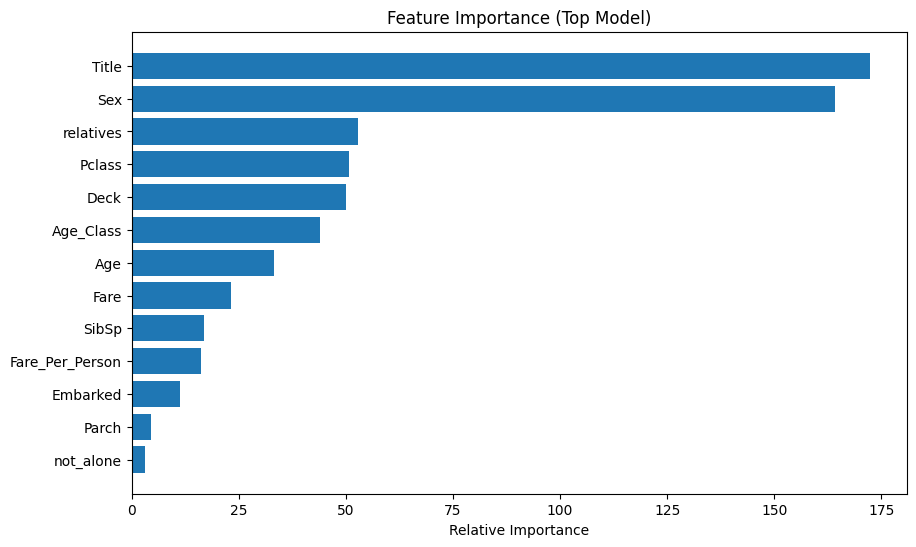

Submission saved!
H2O session _sid_85f4 closed.


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/tmp/ipykernel_3553281/2519296948.py:131: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().shutdown()``.
  h2o.shutdown(prompt=False)


In [ ]:
# -------------------------------
# Advanced H2O ML Pipeline - Accuracy-Focused
# -------------------------------

import h2o
from h2o.automl import H2OAutoML
from h2o.estimators.stackedensemble import H2OStackedEnsembleEstimator
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import time

# -------------------------------
# Initialize H2O Cluster
# -------------------------------
h2o.init(max_mem_size="8G")
h2o.no_progress()

# -------------------------------
# Load Data
# -------------------------------
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test  = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')

test_ids = X_test['PassengerId']
X_test.drop(columns=['PassengerId'], inplace=True)

target = 'Survived'
y_train_numeric = y_train[target]

train_df = X_train.copy()
train_df[target] = y_train_numeric

train_hf = h2o.H2OFrame(train_df)
test_hf  = h2o.H2OFrame(X_test)

features = list(X_train.columns)
target_col = target
train_hf[target_col] = train_hf[target_col].asfactor()

# -------------------------------
# H2O AutoML (Accuracy-Oriented)
# -------------------------------
aml = H2OAutoML(
    max_models=30,               # Explore more models
    seed=42,
    max_runtime_secs=3600,       # 1 hour
    nfolds=5,
    keep_cross_validation_predictions=True,
    sort_metric="mean_per_class_error"  # Focus on minimizing classification error
)

start_time = time.time()
aml.train(x=features, y=target_col, training_frame=train_hf)
end_time = time.time()
print(f"AutoML training completed in {end_time - start_time:.2f} seconds")

# -------------------------------
# Leaderboard
# -------------------------------
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

best_model = aml.leader
print(f"Best model: {best_model.model_id}")

# -------------------------------
# Evaluate CV Accuracy Safely
# -------------------------------
def get_cv_predictions(model):
    """Get CV predictions for accuracy calculation"""
    try:
        cv_preds = model.cross_validation_holdout_predictions()
        if cv_preds is not None:
            prob = h2o.as_list(cv_preds)['p1'].values
            return (prob >= 0.5).astype(int)
        else:
            return None
    except:
        return None

cv_pred_class = get_cv_predictions(best_model)

# If leader is ensemble, pick top non-ensemble model for CV metrics
if cv_pred_class is None:
    print("Leader is ensemble; using top non-ensemble for CV accuracy")
    lb_df = aml.leaderboard.as_data_frame()
    top_model_id = lb_df[~lb_df['model_id'].str.contains("StackedEnsemble")]['model_id'].iloc[0]
    top_model = h2o.get_model(top_model_id)
    cv_pred_class = get_cv_predictions(top_model)
    
cv_acc = accuracy_score(y_train_numeric, cv_pred_class)
print(f"CV Accuracy: {cv_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_train_numeric, cv_pred_class)
print("CV Confusion Matrix:\n", cm)

# -------------------------------
# Feature Importance (Top Non-Ensemble)
# -------------------------------
if 'top_model' in locals() and hasattr(top_model, "varimp"):
    varimp = top_model.varimp(use_pandas=True)
    plt.figure(figsize=(10,6))
    plt.barh(varimp['variable'], varimp['relative_importance'])
    plt.xlabel('Relative Importance')
    plt.title('Feature Importance (Top Model)')
    plt.gca().invert_yaxis()
    plt.show()

# -------------------------------
# Predict on Test Data (Accuracy-Oriented)
# -------------------------------
pred_hf = best_model.predict(test_hf)
pred_df = h2o.as_list(pred_hf)
y_test_proba = pred_df['p1'].values
y_test_class = (y_test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": y_test_class
})
submission.to_csv("h2o_automl_accuracy_submission.csv", index=False)
print("Submission saved!")

# -------------------------------
# Shutdown H2O
# -------------------------------
h2o.shutdown(prompt=False)
